# Growing Neural Gas on synthetic blobs

Train `GrowingNeuralGas` on a simple 2D blob dataset and visualize the learned graph inline.

**Note:** For this example you need to install `matplotlib`.


Link to the original paper : https://proceedings.neurips.cc/paper/1994/file/d56b9fc4b0f1be8871f5e1c40c0067e7-Paper.pdf


In [5]:
#%pip install matplotlib

%matplotlib inline

from __future__ import annotations

import matplotlib.pyplot as plt
import torch

from ngas.models import GrowingNeuralGas

In [3]:
def make_blobs(n_samples: int, seed: int, device: torch.device) -> torch.Tensor:
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)

    centers = torch.tensor(
        [[-2.0, -1.5], [0.5, 2.0], [2.5, -0.5], [2.5, 2.8]],
        dtype=torch.float32,
    )
    chunks = []
    per_center = n_samples // centers.size(0)
    for c in centers:
        points = c + 0.40 * torch.randn(per_center, 2, generator=g)
        chunks.append(points)

    rem = n_samples - per_center * centers.size(0)
    if rem > 0:
        points = centers[0] + 0.40 * torch.randn(rem, 2, generator=g)
        chunks.append(points)

    data = torch.cat(chunks, dim=0)
    perm = torch.randperm(data.size(0), generator=g)
    data = data[perm]
    return data.to(device=device)


def edge_count(adj: torch.Tensor) -> int:
    return int((adj >= 0).sum().item() // 2)


def plot_graph(data: torch.Tensor, model: GrowingNeuralGas) -> None:
    pred = model.predict(data).cpu()
    x = data.cpu()
    w = model.weights.cpu()
    adj = model.adj.cpu()

    plt.figure(figsize=(8, 6))
    plt.scatter(x[:, 0], x[:, 1], c=pred, s=18, alpha=0.55, cmap="tab20")
    plt.scatter(w[:, 0], w[:, 1], c="black", s=85, marker="x", linewidths=2)

    idx = torch.triu_indices(adj.size(0), adj.size(1), offset=1)
    for i, j in zip(idx[0], idx[1]):
        if int(adj[i, j].item()) >= 0:
            p = w[i]
            q = w[j]
            plt.plot([p[0], q[0]], [p[1], q[1]], color="black", linewidth=0.8, alpha=0.4)

    plt.title("Growing Neural Gas on Synthetic Blobs")
    plt.tight_layout()
    plt.show()

nodes=64
edges=135
quantization_error=0.167651


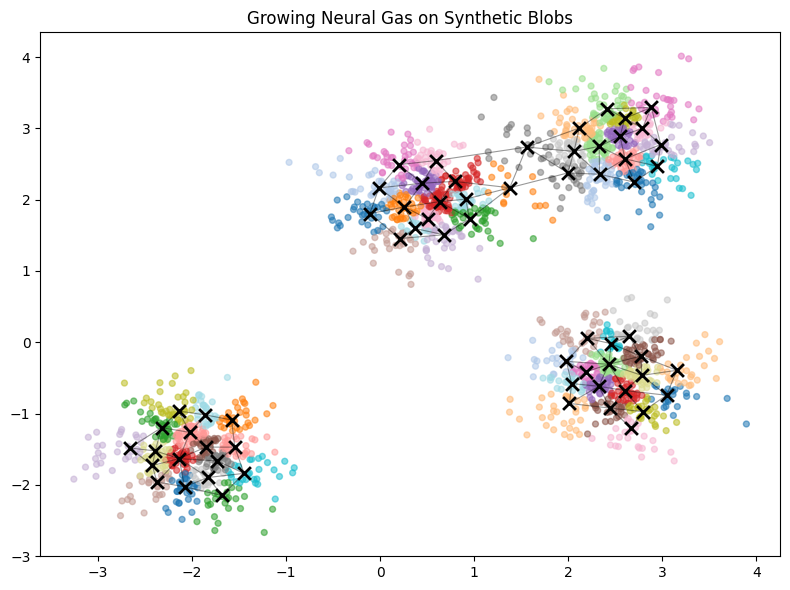

In [4]:
N_SAMPLES = 2000
MAX_NEURONS = 64
EPOCHS = 4
LR_WINNER = 0.05
LR_NEIGHBOR = 0.006
MAX_EDGE_AGE = 80
LAMBDA_STEPS = 100
ALPHA = 0.5
BETA = 0.0005
DISTANCE = "l2"
SEED = 13
DEVICE = torch.device("cpu")

###################################

torch.manual_seed(SEED)

data = make_blobs(n_samples=N_SAMPLES, seed=SEED, device=DEVICE)
model = GrowingNeuralGas(
    max_neurons=MAX_NEURONS,
    lr_winner=LR_WINNER,
    lr_neighbor=LR_NEIGHBOR,
    max_edge_age=MAX_EDGE_AGE,
    lambda_steps=LAMBDA_STEPS,
    alpha=ALPHA,
    beta=BETA,
    distance=DISTANCE,
    device=DEVICE,
)

model.fit(data, epochs=EPOCHS, shuffle=True)
qerr = model.quantization_error(data)

print(f"nodes={model.n_nodes}")
print(f"edges={edge_count(model.adj)}")
print(f"quantization_error={qerr:.6f}")

plot_graph(data, model)